In [2]:
# search and download EIS files 
# in command line 
# `eis_catalog`

In [3]:
# explore the file with `eis_explore_raster` in the terminal 

In [1]:
import eispac 
import sunpy 
import sunpy.map 
import matplotlib.pyplot as plt 
from astropy.visualization import ImageNormalize, AsinhStretch
import numpy as np 

In [2]:
# load the data cube 
# similar to eis_getwindata() in IDL

l1_filename = "../data/eis_20221025_002341.data.h5"
eis_cube = eispac.read_cube(l1_filename, 195) # load the Fe XII 195 window 

Data file,
   /home/yjzhu/Solar/learn_python_pmod/data/eis_20221025_002341.data.h5
Header file,
   /home/yjzhu/Solar/learn_python_pmod/data/eis_20221025_002341.head.h5
Found a wavelength 195.00 [Angstroms] in window 8


In [3]:
# need a template for fitting from terminal
# from `eis_browse_template`
# load the template 
FeXII_template_filename = "../data/eis/fe_12_195_119.1c.template.h5"
eis_FeXII_195_template = eispac.read_template(FeXII_template_filename)

In [4]:
# we dont have to fit it again
# eis_FeXII_195_fitres = eispac.fit_spectra(eis_cube, template=eis_FeXII_195_template,
#                                          ncpu=4)

In [5]:
# eispac.save_fit(eis_FeXII_195_fitres, save_dir="../data/eis/")

In [6]:
eis_FeXII_195_fitres = eispac.read_fit("../data/eis/eis_20221025_002341.fe_12_195_119.1c-0.fit.h5")

Reading fit result from, 
   ../data/eis/eis_20221025_002341.fe_12_195_119.1c-0.fit.h5


In [8]:
eis_FeXII_195_fitres.fit.keys()

dict_keys(['chi2', 'component', 'err_int', 'err_vel', 'err_width', 'int', 'line_ids', 'main_component', 'mask', 'n_gauss', 'n_poly', 'param_names', 'param_units', 'params', 'perror', 'status', 'vel', 'wave_range', 'wavelength', 'width'])

In [13]:
# help(eis_FeXII_195_fitres.fit)

In [14]:
# help(eis_FeXII_195_fitres)

In [10]:
# dictionary 

dict_0 = {"chi2":0}

print(dict_0["chi2"])

0


In [9]:
# get the chi2 array 

chi2_array = eis_FeXII_195_fitres.fit["chi2"]

In [15]:
# plot the intensity map 
FeXII_195_intmap = eis_FeXII_195_fitres.get_map(component=0, measurement="intensity")

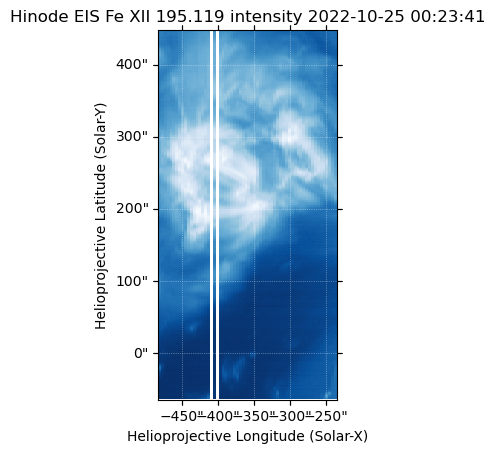

In [16]:
FeXII_195_intmap.plot()

In [18]:
# get the intensity array 
FeXII_195_int_array = FeXII_195_intmap.data

In [21]:
type(FeXII_195_int_array)

numpy.ndarray

In [24]:
print(FeXII_195_int_array.shape, FeXII_195_int_array.dtype)

(512, 62) float64


In [23]:
# help(FeXII_195_int_array)

In [19]:
print(np.nanmin(FeXII_195_int_array), np.nanmax(FeXII_195_int_array))

0.0 2679.89945080428


In [20]:
print(FeXII_195_int_array.min(), FeXII_195_int_array.max())

0.0 2679.89945080428


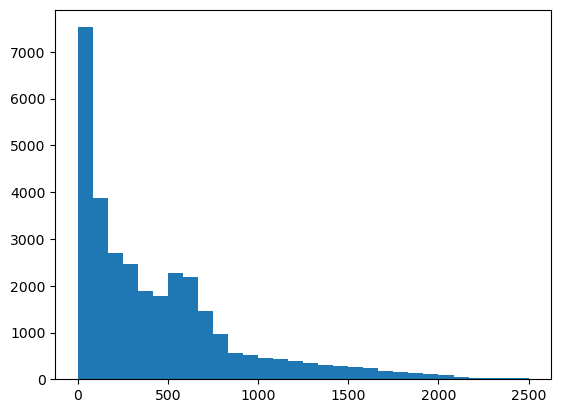

In [28]:
# plot histogram 

fig, ax = plt.subplots()
# _ = will discard the outputs from ax.hist()
_ = ax.hist(FeXII_195_int_array.flatten(), range=(0, 2500), bins=30)

In [30]:
# save the intensity map into a FITS file

FeXII_195_intmap.save("../data/eis_20221025_002341.FeXII_195.intensity.fits",
                        overwrite=True)